# 05 · Feature Engineering — 03. Dataset para similitud entre jugadores

Tercer notebook de la fase 05. Construye los datasets de entrada para el **sistema de similitud entre
jugadores** a partir de `master_filtered.csv` (14.202 filas) generado en 05_01.

## Objetivo

Producir **dos datasets** separados (uno para outfielders, otro para porteros), cada uno con jugadores
representados como vectores en un espacio reducido por PCA. Sobre estos vectores se calcularán
distancias (k-NN, distancia euclídea o coseno) en la fase 06 para responder a:

> *"¿Qué jugadores tienen un perfil estadístico parecido al jugador X?"*

Combinado con el modelo de regresión salarial (05_02 → 06_regresion), permite la **funcionalidad clave
del TFM**: detectar jugadores sobrepagados y proponer reemplazos con perfil similar y salario inferior.

## Diferencias respecto al dataset de regresión (05_02)

El sistema de similitud tiene necesidades muy distintas al de regresión, lo que justifica un FE
específico:

| Aspecto | Regresión (05_02) | Similitud (05_03) |
|---|---|---|
| Filtro de salario | Sí (target obligatorio) | **No** (más candidatos) |
| Variables contextuales (país, temporada, nacionalidad) | Sí, como features | **No** (queremos similitud por *estilo*, no contextual) |
| Reducción dimensional | Selección por cluster (~70 features) | **PCA agresivo** (~15 PCs) por la maldición de la dimensionalidad |
| Estandarización | No necesaria (modelos de árbol) | **Obligatoria** (RobustScaler) — distancias euclídeas |
| Tratamiento de posiciones | One-hot como feature | **Datasets separados** (outfielders vs keepers) |
| `age` como feature | Sí (`age` y `age²`) | Solo metadato (filtros post-hoc) |

## Decisiones de diseño

1. **No filtrar por salario**: el universo de candidatos para sugerir reemplazos incluye canteranos,
   cesiones y jugadores sin ficha registrada en Capology.
2. **Excluir `country`, `season`, `nationality`** del vector de similitud: queremos que dos jugadores
   con estilo idéntico salgan como similares aunque jueguen en ligas o temporadas distintas.
3. **`age` y `position` como metadatos** (no entran al cálculo): se conservan para permitir filtros
   post-consulta del tipo *"jugadores similares a X con edad ≤ 25"* o *"que jueguen en otra liga"*.
4. **Datasets separados outfielders/keepers**: las stats relevantes son drásticamente distintas
   (un portero tiene 50+ saves y 0 goles; un delantero al revés). Mezclarlos genera ruido en el cálculo
   de distancias.
5. **PCA global**: ~15-18 componentes para outfielders (~80% varianza), ~5-7 para keepers.
6. **RobustScaler** (mediana/IQR): coherente con el uso sistemático de la mediana en el resto del TFM
   y robusto a los outliers que generan las stats per-90 sobre minutos pequeños.

## Pasos del notebook

1. Imports y carga del dataset filtrado.
2. Split por posición (outfielders vs keepers).
3. Selección de features de rendimiento, diferenciada por grupo.
4. Tratamiento de NaN estructurales.
5. Normalización per-90.
6. Estandarización con RobustScaler (uno por grupo).
7. PCA + análisis de varianza explicada.
8. Validación cualitativa (jugadores conocidos y sus similares).
9. Guardado de datasets transformados con metadatos.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT      = Path.cwd().parents[1]
FILTERED  = ROOT / 'data' / 'clean'   / 'master_filtered.csv'
OUT_DIR   = ROOT / 'data' / 'modeling' / 'similarity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FILTERED, dtype={'season': str})
print(f'Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')
df['position'].value_counts()

Dataset cargado: 14,202 filas × 121 columnas


position
D    5162
F    4685
M    3316
K    1039
Name: count, dtype: int64

## 2. Split por posición: outfielders vs keepers

Las stats que caracterizan a un portero son completamente distintas a las que definen a un jugador de
campo. Mezclarlos en un mismo espacio de similitud generaría resultados absurdos: la mediana per-90
de `saves` para porteros es 2.88 frente a 0.00 para outfielders; la mediana de `keyPasses` es 0.00
para porteros frente a 0.83 para outfielders.

Por eso se construyen **dos datasets independientes**, cada uno con sus features relevantes.

In [2]:
df_keepers    = df[df['position'] == 'K'].copy()
df_outfielders = df[df['position'] != 'K'].copy()

print(f'Outfielders: {len(df_outfielders):,} filas')
print(f'Keepers:     {len(df_keepers):,} filas')
print(f'Total:       {len(df_outfielders) + len(df_keepers):,} (debe coincidir con master_filtered)')

Outfielders: 13,163 filas
Keepers:     1,039 filas
Total:       14,202 (debe coincidir con master_filtered)


## 3. Selección de features de rendimiento

Para cada grupo se selecciona un núcleo de features que **realmente caractericen el estilo de juego**
en esa posición. Se aplican criterios complementarios:

- **Para outfielders**: estilo ofensivo (definición, creación), técnico (pase, regate) y defensivo
  (duelos, intercepciones). Se excluyen las stats puramente de portería.
- **Para keepers**: stats de portería (saves, salidas, paradas, claims) más alguna defensiva genérica
  como duelos aéreos. Se excluyen ataque y creación (siempre 0 o casi 0).

Además, en ambos casos se aplican las decisiones del 05_02:

- Eliminar redundancias críticas (pares con r ≥ 0.95 del análisis de 04_04).
- Excluir variables contextuales (`country`, `season`, `nationality`).
- Mantener `player`, `team`, `country`, `season`, `age`, `position` como **metadatos** (viajan en
  el dataset pero no entran al PCA).

### 3.1 Features para outfielders

In [3]:
# Núcleo de stats que caracterizan a un jugador de campo
# Cubren las 5 facetas naturales identificadas en el clustering del 04_04:
# Volumen/Pase, Creación, Definición, Duelos/Defensa, Acción individual

FEATURES_OUTFIELDERS = [
    # Volumen y pase
    'accuratePasses', 'accurateFinalThirdPasses', 'touches', 'inaccuratePasses',
    'possessionLost', 'accuratePassesPercentage',

    # Pases largos y cruces
    'accurateLongBalls', 'accurateChippedPasses', 'accurateLongBallsPercentage',
    'totalCross', 'accurateCrossesPercentage',

    # Creación
    'assists', 'expectedAssists', 'keyPasses', 'bigChancesCreated',

    # Definición
    'goals', 'expectedGoals', 'totalShots', 'shotsOnTarget', 'bigChancesMissed',
    'goalConversionPercentage', 'shotsFromOutsideTheBox', 'headedGoals', 'leftFootGoals',

    # Acción individual / regate
    'successfulDribbles', 'successfulDribblesPercentage', 'dispossessed',
    'possessionWonAttThird',

    # Duelos
    'aerialDuelsWon', 'aerialLost', 'aerialDuelsWonPercentage',
    'groundDuelsWon', 'groundDuelsWonPercentage',
    'totalDuelsWon', 'totalDuelsWonPercentage',
    'fouls', 'wasFouled',

    # Defensa
    'tackles', 'tacklesWonPercentage', 'interceptions', 'clearances',
    'blockedShots', 'dribbledPast', 'errorLeadToShot', 'errorLeadToGoal',

    # Volumen / exposición (no per-90, son contextuales pero informativos)
    'minutesPlayed', 'appearances',

    # Rating y reconocimiento
    'rating', 'totwAppearances',

    # Otras
    'offsides', 'yellowCards', 'redCards',
]

# Filtrar las que realmente existen en el dataset
FEATURES_OUTFIELDERS = [c for c in FEATURES_OUTFIELDERS if c in df_outfielders.columns]
print(f'Features para outfielders: {len(FEATURES_OUTFIELDERS)}')

Features para outfielders: 52


### 3.2 Features para keepers

Para porteros el espacio es mucho más reducido — la cobertura de Sofascore en stats de portería es
limitada y muchos eventos son raros. Se mantiene un núcleo compacto centrado en las acciones que
definen el rendimiento de un guardameta.

In [4]:
FEATURES_KEEPERS = [
    # Paradas
    'saves', 'goalsPrevented',

    # Salidas y juego aéreo
    'highClaims', 'punches', 'runsOut',
    'crossesNotClaimed', 'savesCaught',

    # Resultado defensivo
    'goalsConceded', 'cleanSheet',
    'goalsConcededInsideTheBox', 'goalsConcededOutsideTheBox',

    # Penaltis
    'penaltyFaced', 'penaltySave',

    # Pase desde portería
    'accuratePasses', 'accuratePassesPercentage',
    'accurateLongBalls', 'accurateLongBallsPercentage',
    'goalKicks',

    # Volumen / exposición
    'minutesPlayed', 'appearances',

    # Rating y reconocimiento
    'rating', 'totwAppearances',

    # Otras (errores)
    'errorLeadToShot', 'errorLeadToGoal',
]

FEATURES_KEEPERS = [c for c in FEATURES_KEEPERS if c in df_keepers.columns]
print(f'Features para keepers: {len(FEATURES_KEEPERS)}')

Features para keepers: 24


## 4. Tratamiento de NaN estructurales

Misma lógica que en 05_02: las stats `expectedGoals`, `expectedAssists` y `ballRecovery` no están
disponibles uniformemente en todas las temporadas. Para similitud, se imputan a 0 (sin flags, ya que
los flags solo tienen sentido como features para modelos predictivos, no para distancias).

`goalsPrevented` (variable de portero) sí se mantiene en su forma original; los pocos NaN que queden
en el subset de keepers se imputan a 0.

In [5]:
# Imputar NaN en las features que vamos a usar
for col in ['expectedGoals', 'expectedAssists', 'ballRecovery']:
    if col in df_outfielders.columns:
        df_outfielders[col] = df_outfielders[col].fillna(0)
    if col in df_keepers.columns:
        df_keepers[col] = df_keepers[col].fillna(0)

# Otros NaN puntuales en stats numéricas
for col in FEATURES_OUTFIELDERS:
    n_nan = df_outfielders[col].isna().sum()
    if n_nan > 0:
        df_outfielders[col] = df_outfielders[col].fillna(0)

for col in FEATURES_KEEPERS:
    n_nan = df_keepers[col].isna().sum()
    if n_nan > 0:
        df_keepers[col] = df_keepers[col].fillna(0)

print('Outfielders NaN restantes:', df_outfielders[FEATURES_OUTFIELDERS].isna().sum().sum())
print('Keepers NaN restantes:    ', df_keepers[FEATURES_KEEPERS].isna().sum().sum())

Outfielders NaN restantes: 0
Keepers NaN restantes:     0


## 5. Normalización per-90 minutos

Igual que en 05_02: stats acumulables → tasa por 90 minutos. Se mantienen sin transformar:
- Ratios y porcentajes (`*Percentage`).
- `rating` (media ponderada por partido).
- `appearances` y `minutesPlayed` (variables de exposición — informativas como tales).
- `totwAppearances` (reconocimiento, no escala linealmente con minutos).

In [6]:
# Variables que NO se per-90-zan
NO_PER90 = {
    'minutesPlayed', 'appearances', 'rating', 'totwAppearances',
    # Porcentajes
    'accurateCrossesPercentage', 'accurateLongBallsPercentage', 'accuratePassesPercentage',
    'aerialDuelsWonPercentage', 'goalConversionPercentage', 'groundDuelsWonPercentage',
    'successfulDribblesPercentage', 'tacklesWonPercentage', 'totalDuelsWonPercentage',
}

def aplicar_per90(df_grupo, features):
    """Convierte stats acumulables a tasa per-90 manteniendo NO_PER90 sin transformar."""
    df_grupo = df_grupo.copy()
    mins = df_grupo['minutesPlayed'].replace(0, np.nan)
    nuevas_features = []

    for col in features:
        if col in NO_PER90:
            nuevas_features.append(col)
        else:
            new_col = f'{col}_per90'
            df_grupo[new_col] = df_grupo[col] / mins * 90
            nuevas_features.append(new_col)

    return df_grupo, nuevas_features

df_outfielders, FEATS_OF_FINAL = aplicar_per90(df_outfielders, FEATURES_OUTFIELDERS)
df_keepers,     FEATS_K_FINAL  = aplicar_per90(df_keepers,     FEATURES_KEEPERS)

print(f'Features finales outfielders: {len(FEATS_OF_FINAL)}')
print(f'Features finales keepers:    {len(FEATS_K_FINAL)}')

# Verificación
print(f'\nNaN/Inf outfielders: {df_outfielders[FEATS_OF_FINAL].isna().sum().sum()} / {np.isinf(df_outfielders[FEATS_OF_FINAL]).sum().sum()}')
print(f'NaN/Inf keepers:     {df_keepers[FEATS_K_FINAL].isna().sum().sum()} / {np.isinf(df_keepers[FEATS_K_FINAL]).sum().sum()}')

Features finales outfielders: 52
Features finales keepers:    24

NaN/Inf outfielders: 0 / 0
NaN/Inf keepers:     0 / 0


## 6. Estandarización con RobustScaler

Antes de aplicar PCA es **imprescindible estandarizar**: sin escalado, las stats con valores grandes
(como `touches_per90` con valores de 50-90) dominarían sobre las pequeñas (como `goals_per90` con
valores de 0-1). El PCA es sensible a la escala porque maximiza varianza, y la varianza absoluta
depende de la escala de cada variable.

Se elige **`RobustScaler`** sobre `StandardScaler` por dos motivos:

1. **Robusto a outliers**: usa **mediana** e **IQR** (rango intercuartílico) en lugar de media y
   desviación estándar. Las stats per-90 tienen outliers extremos por construcción (un delantero con
   pocos minutos y 1 gol da `goals_per90 ≈ 1.0` cuando la mediana es 0.05). Con StandardScaler estos
   outliers comprimirían artificialmente el rango del resto del dataset.
2. **Coherencia metodológica con el resto del TFM**: el README documenta el uso sistemático de la
   mediana como medida de tendencia central, por la asimetría de los datos.

Se entrena un scaler **distinto para cada grupo** porque la escala típica de las stats es muy diferente
entre porteros y outfielders.

In [7]:
# Outfielders
scaler_of = RobustScaler()
X_of_scaled = scaler_of.fit_transform(df_outfielders[FEATS_OF_FINAL])
print(f'Outfielders: matriz escalada {X_of_scaled.shape}')

# Keepers
scaler_k = RobustScaler()
X_k_scaled = scaler_k.fit_transform(df_keepers[FEATS_K_FINAL])
print(f'Keepers:     matriz escalada {X_k_scaled.shape}')

# Verificación rápida: tras RobustScaler la mediana debería ser 0 y el IQR ≈ 1
print(f'\nOutfielders — mediana media: {np.median(X_of_scaled, axis=0).mean():.4f} (esperado ≈ 0)')
print(f'Keepers     — mediana media: {np.median(X_k_scaled, axis=0).mean():.4f} (esperado ≈ 0)')

Outfielders: matriz escalada (13163, 52)
Keepers:     matriz escalada (1039, 24)

Outfielders — mediana media: 0.0000 (esperado ≈ 0)
Keepers     — mediana media: 0.0000 (esperado ≈ 0)


## 7. PCA

El **Análisis de Componentes Principales** (PCA) reduce la dimensionalidad del espacio de features
proyectándolo a un nuevo espacio de combinaciones lineales ortogonales que **maximizan la varianza**.

### ¿Por qué PCA aquí?

1. **Mitigar la maldición de la dimensionalidad**: en espacios de >50 dimensiones, las distancias
   entre puntos tienden a igualarse y k-NN pierde discriminación.
2. **Eliminar redundancia residual**: aunque ya hicimos selección por cluster, persiste correlación
   moderada entre muchas features. PCA la captura en un solo eje.
3. **Preparar el espacio para distancias euclídeas**: PCA descorrelaciona los ejes, por lo que la
   distancia euclídea en el espacio de PCs tiene una interpretación más limpia que en el espacio
   original.
4. **Visualización**: los primeros 2-3 PCs son útiles para representar a los jugadores en gráficos 2D
   en el Streamlit final.

### Estrategia

Se ajusta un PCA inicialmente con todas las componentes (n_components = nº features), se inspecciona
la varianza explicada, y se elige un umbral del **80-85%** que típicamente recoge la dimensión
intrínseca del dataset. El EDA del 04_04 ya estimó que ~22 PCs capturan el 80% de la varianza
en el dataset completo; aquí esperamos cifras similares para outfielders y bastante más reducidas
para keepers (al tener muchas menos features).

### 7.1 PCA exploratorio: varianza explicada

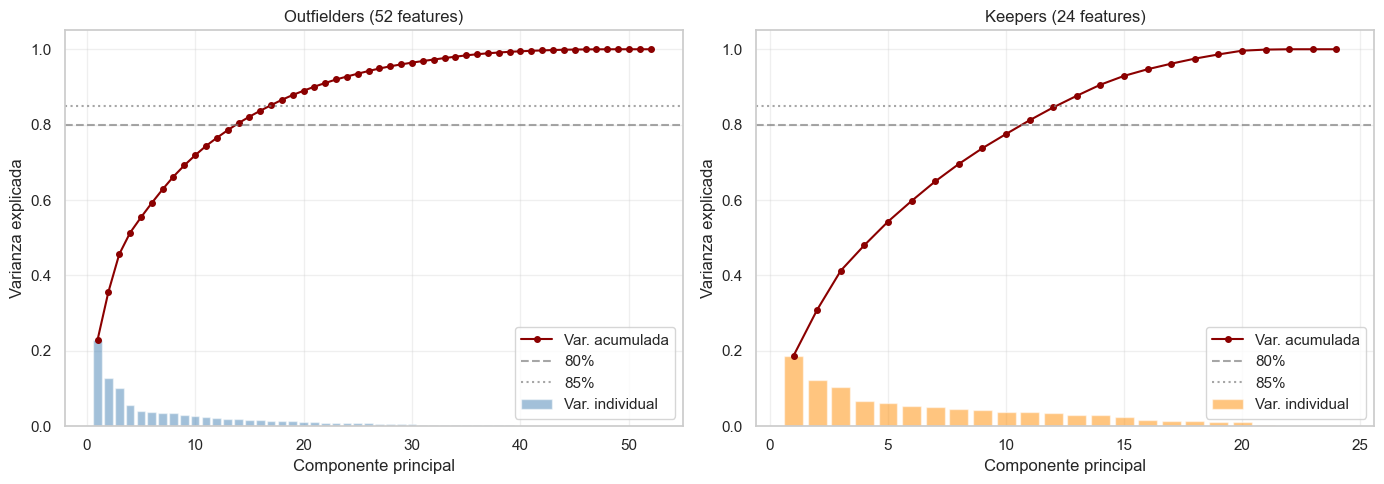


=== Outfielders ===
  PCs para 80% varianza: 14
  PCs para 85% varianza: 17
  PCs para 90% varianza: 21

=== Keepers ===
  PCs para 80% varianza: 11
  PCs para 85% varianza: 13
  PCs para 90% varianza: 14


In [8]:
# Outfielders: PCA con todas las componentes
pca_of_full = PCA()
pca_of_full.fit(X_of_scaled)
var_explained_of = pca_of_full.explained_variance_ratio_
cum_var_of = np.cumsum(var_explained_of)

# Keepers
pca_k_full = PCA()
pca_k_full.fit(X_k_scaled)
var_explained_k = pca_k_full.explained_variance_ratio_
cum_var_k = np.cumsum(var_explained_k)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outfielders
ax = axes[0]
n_of = len(var_explained_of)
ax.bar(range(1, n_of+1), var_explained_of, alpha=0.5, label='Var. individual', color='steelblue')
ax.plot(range(1, n_of+1), cum_var_of, color='darkred', marker='o', markersize=4, label='Var. acumulada')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.7, label='80%')
ax.axhline(0.85, color='gray', linestyle=':', alpha=0.7, label='85%')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada')
ax.set_title(f'Outfielders ({n_of} features)')
ax.legend()
ax.grid(alpha=0.3)

# Keepers
ax = axes[1]
n_k = len(var_explained_k)
ax.bar(range(1, n_k+1), var_explained_k, alpha=0.5, label='Var. individual', color='darkorange')
ax.plot(range(1, n_k+1), cum_var_k, color='darkred', marker='o', markersize=4, label='Var. acumulada')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.7, label='80%')
ax.axhline(0.85, color='gray', linestyle=':', alpha=0.7, label='85%')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada')
ax.set_title(f'Keepers ({n_k} features)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar el nº de componentes para los umbrales
def n_componentes_para(cum_var, umbral):
    return int(np.argmax(cum_var >= umbral)) + 1

print(f'\n=== Outfielders ===')
print(f'  PCs para 80% varianza: {n_componentes_para(cum_var_of, 0.80)}')
print(f'  PCs para 85% varianza: {n_componentes_para(cum_var_of, 0.85)}')
print(f'  PCs para 90% varianza: {n_componentes_para(cum_var_of, 0.90)}')

print(f'\n=== Keepers ===')
print(f'  PCs para 80% varianza: {n_componentes_para(cum_var_k, 0.80)}')
print(f'  PCs para 85% varianza: {n_componentes_para(cum_var_k, 0.85)}')
print(f'  PCs para 90% varianza: {n_componentes_para(cum_var_k, 0.90)}')

### 7.2 Ajustar PCA con el nº de componentes elegido

Se elige el umbral del **85% de varianza explicada** como compromiso entre fidelidad al dataset
original y reducción efectiva de dimensionalidad. Esto típicamente captura toda la estructura
relevante del dataset eliminando ruido residual.

In [9]:
# Elegir nº de componentes (85% varianza)
N_PCS_OF = n_componentes_para(cum_var_of, 0.85)
N_PCS_K  = n_componentes_para(cum_var_k,  0.85)

# Ajustar PCA definitivos
pca_of = PCA(n_components=N_PCS_OF, random_state=42)
X_of_pca = pca_of.fit_transform(X_of_scaled)

pca_k = PCA(n_components=N_PCS_K, random_state=42)
X_k_pca = pca_k.fit_transform(X_k_scaled)

print(f'Outfielders: {X_of_pca.shape[1]} PCs explican {pca_of.explained_variance_ratio_.sum()*100:.1f}% de la varianza')
print(f'Keepers:     {X_k_pca.shape[1]} PCs explican {pca_k.explained_variance_ratio_.sum()*100:.1f}% de la varianza')

Outfielders: 17 PCs explican 85.2% de la varianza
Keepers:     13 PCs explican 87.7% de la varianza


### 7.3 Interpretación de los primeros componentes (loadings)

Los **loadings** son las correlaciones entre cada feature original y cada componente principal.
Permiten entender qué "concepto futbolístico" representa cada PC. Para los primeros 3 PCs (los más
relevantes en la estructura del dataset) mostramos las features con mayor peso absoluto.

In [10]:
def mostrar_top_loadings(pca, feature_names, n_top=10, n_pcs=3, titulo=''):
    """Imprime las features con mayor peso (en valor absoluto) en cada uno de los primeros n_pcs."""
    print(f'\n=== {titulo} ===')
    loadings = pca.components_[:n_pcs]
    for i, pc in enumerate(loadings):
        var_pct = pca.explained_variance_ratio_[i] * 100
        idx_sorted = np.argsort(np.abs(pc))[::-1][:n_top]
        print(f'\nPC{i+1} ({var_pct:.1f}% var.) — top features:')
        for idx in idx_sorted:
            sign = '+' if pc[idx] >= 0 else '-'
            print(f'  {sign} {feature_names[idx]:<40} {pc[idx]:+.3f}')

mostrar_top_loadings(pca_of, FEATS_OF_FINAL, n_top=10, n_pcs=3, titulo='OUTFIELDERS')
mostrar_top_loadings(pca_k,  FEATS_K_FINAL,  n_top=10, n_pcs=3, titulo='KEEPERS')


=== OUTFIELDERS ===

PC1 (22.9% var.) — top features:
  + leftFootGoals_per90                      +0.299
  + expectedGoals_per90                      +0.264
  + offsides_per90                           +0.249
  + goals_per90                              +0.246
  + bigChancesMissed_per90                   +0.242
  + shotsOnTarget_per90                      +0.232
  + totalShots_per90                         +0.210
  + headedGoals_per90                        +0.201
  + blockedShots_per90                       +0.184
  - clearances_per90                         -0.177

PC2 (12.7% var.) — top features:
  + totwAppearances                          +0.353
  - aerialLost_per90                         -0.323
  + accurateFinalThirdPasses_per90           +0.276
  - headedGoals_per90                        -0.271
  - aerialDuelsWon_per90                     -0.224
  + rating                                   +0.219
  + touches_per90                            +0.211
  + keyPasses_per90        

### 7.4 Visualización 2D del espacio de similitud

Se proyectan los jugadores sobre los dos primeros PCs y se colorean por posición (en outfielders) y
por liga (en keepers, donde no hay subdivisión por posición), para verificar visualmente que el espacio
está capturando estructura significativa.

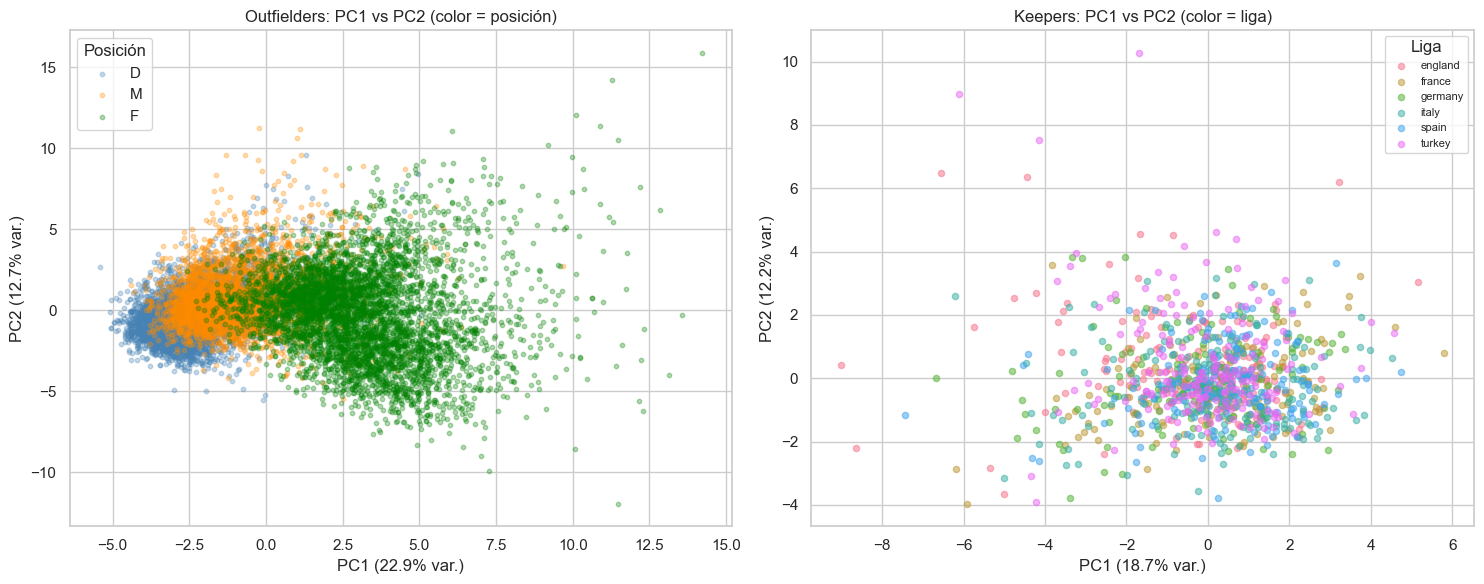

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Outfielders coloreado por posición específica
ax = axes[0]
for pos, color in zip(['D', 'M', 'F'], ['steelblue', 'darkorange', 'green']):
    mask = df_outfielders['position'] == pos
    ax.scatter(X_of_pca[mask, 0], X_of_pca[mask, 1],
               alpha=0.3, s=10, c=color, label=pos)
ax.set_xlabel(f'PC1 ({pca_of.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca_of.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('Outfielders: PC1 vs PC2 (color = posición)')
ax.legend(title='Posición')

# Keepers coloreado por liga
ax = axes[1]
ligas = df_keepers['country'].unique()
palette = sns.color_palette('husl', n_colors=len(ligas))
for liga, color in zip(ligas, palette):
    mask = df_keepers['country'] == liga
    ax.scatter(X_k_pca[mask, 0], X_k_pca[mask, 1],
               alpha=0.5, s=20, c=[color], label=liga)
ax.set_xlabel(f'PC1 ({pca_k.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca_k.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('Keepers: PC1 vs PC2 (color = liga)')
ax.legend(title='Liga', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Validación cualitativa: jugadores conocidos y sus similares

La mejor forma de validar un sistema de similitud es el **sentido común futbolístico**: si introduces
a Vinicius Jr., los más similares deberían ser otros extremos rápidos y verticales. Si introduces a
Modric, deberían salir mediocentros creativos con mucho pase. Si los resultados son absurdos
(Vinicius similar a Casemiro), hay un problema en el FE.

Aquí calculamos distancias euclídeas en el espacio PCA y mostramos los 5 más cercanos a algunos
jugadores conocidos. Esta validación es **previa al modelo k-NN propiamente dicho** (eso será del 06).

In [12]:
def encontrar_similares(nombre_jugador, df_grupo, X_pca, top_n=5):
    """Devuelve los top_n jugadores más cercanos al jugador dado en el espacio PCA."""
    # Buscar el jugador (puede haber varias temporadas)
    matches = df_grupo[df_grupo['player'].str.contains(nombre_jugador, case=False, na=False)]
    if len(matches) == 0:
        print(f'❌ No encontrado: {nombre_jugador}')
        return None

    # Tomamos la temporada más reciente del jugador
    matches_sorted = matches.sort_values('season', ascending=False)
    idx_jugador = matches_sorted.index[0]

    # Posición original en el array X_pca
    pos_array = df_grupo.index.get_loc(idx_jugador)
    vec_jugador = X_pca[pos_array].reshape(1, -1)

    # Distancias a todos los demás
    distancias = euclidean_distances(vec_jugador, X_pca).flatten()

    # Top N (excluyendo el propio jugador-temporada)
    idx_ordenados = np.argsort(distancias)
    top_idx = idx_ordenados[1:top_n+1]  # [1:] saltar el propio (distancia 0)

    print(f'\n🎯 Similares a {df_grupo.loc[idx_jugador, "player"]} '
          f'({df_grupo.loc[idx_jugador, "team"]}, {df_grupo.loc[idx_jugador, "season"]}, '
          f'{df_grupo.loc[idx_jugador, "position"]}):')

    for i, pos in enumerate(top_idx, 1):
        idx_orig = df_grupo.index[pos]
        row = df_grupo.loc[idx_orig]
        print(f'  {i}. {row["player"]:<30} ({row["team"]:<25} {row["season"]} {row["position"]}) '
              f'  dist={distancias[pos]:.2f}')

    return top_idx

# Probar con jugadores conocidos
print('='*80)
print('VALIDACIÓN OUTFIELDERS')
print('='*80)
for jugador in ['Vinicius', 'Modric', 'Lewandowski', 'Van Dijk', 'Kroos']:
    encontrar_similares(jugador, df_outfielders, X_of_pca, top_n=5)

print('\n' + '='*80)
print('VALIDACIÓN KEEPERS')
print('='*80)
for jugador in ['Courtois', 'Oblak', 'Alisson']:
    encontrar_similares(jugador, df_keepers, X_k_pca, top_n=5)

VALIDACIÓN OUTFIELDERS

🎯 Similares a Vinicius Júnior (Real Madrid, 2526, F):
  1. Vinicius Júnior                (Real Madrid               2425 F)   dist=2.83
  2. Khvicha Kvaratskhelia          (Napoli                    2324 F)   dist=3.16
  3. Khvicha Kvaratskhelia          (Napoli                    2223 F)   dist=3.38
  4. Rafael Leão                    (Milan                     2324 F)   dist=3.52
  5. Matheus Cunha                  (Wolverhampton             2425 F)   dist=3.64
❌ No encontrado: Modric

🎯 Similares a Robert Lewandowski (FC Barcelona, 2526, F):
  1. Ermedin Demirović              (VfB Stuttgart             2425 F)   dist=3.71
  2. Joselu                         (Real Madrid               2324 F)   dist=3.96
  3. Odsonne Édouard                (RC Lens                   2526 F)   dist=3.97
  4. Callum Wilson                  (Newcastle United          2223 F)   dist=4.13
  5. Darwin Núñez                   (Liverpool                 2223 F)   dist=4.36

🎯 Simila

## 9. Guardado de los datasets

Se guardan dos CSVs, cada uno con:
- **Metadatos** (no entran al cálculo de distancias pero permiten filtrar después): `player_id`,
  `player`, `team`, `country`, `season`, `position`, `age`, `gross_annual_eur`.
- **Componentes PCA** (PC1, PC2, ..., PCn) que constituyen el vector de similitud.

In [13]:
META_COLS = ['player_id', 'player', 'team', 'country', 'season', 'position', 'age',
             'gross_annual_eur']

# Outfielders
pc_cols_of = [f'PC{i+1}' for i in range(N_PCS_OF)]
df_out_of = df_outfielders[META_COLS].reset_index(drop=True).copy()
df_out_of[pc_cols_of] = X_of_pca

# Keepers
pc_cols_k = [f'PC{i+1}' for i in range(N_PCS_K)]
df_out_k = df_keepers[META_COLS].reset_index(drop=True).copy()
df_out_k[pc_cols_k] = X_k_pca

# Guardar
out_of = OUT_DIR / 'similitud_outfielders.csv'
out_k  = OUT_DIR / 'similitud_keepers.csv'

df_out_of.to_csv(out_of, index=False)
df_out_k.to_csv(out_k,  index=False)

print(f'✓ Guardado: {out_of}')
print(f'  Shape: {df_out_of.shape}  |  {out_of.stat().st_size/1024:.1f} KB')

print(f'\n✓ Guardado: {out_k}')
print(f'  Shape: {df_out_k.shape}  |  {out_k.stat().st_size/1024:.1f} KB')

✓ Guardado: d:\USER\Desktop\TFM\data\modeling\similarity\similitud_outfielders.csv
  Shape: (13163, 25)  |  5103.6 KB

✓ Guardado: d:\USER\Desktop\TFM\data\modeling\similarity\similitud_keepers.csv
  Shape: (1039, 21)  |  324.0 KB


## 10. Resumen del notebook

### Decisiones aplicadas

1. **Sin filtro de salario**: 14.202 filas conservadas (universo completo de candidatos).
2. **Split por posición**: outfielders (~13.163) y keepers (~1.039) tratados como dominios distintos.
3. **Features específicas** por grupo, eliminando contextuales (`country`, `season`, `nationality`).
4. **Imputación a 0** de NaN estructurales (xG, xA, ballRecovery, goalsPrevented) sin flags.
5. **Normalización per-90** en stats acumulables.
6. **RobustScaler** (mediana/IQR) para escalar antes de PCA.
7. **PCA con umbral del 85%** de varianza explicada.
8. **Metadatos preservados** en el output (`player_id`, `team`, `season`, `age`, `position`,
   `gross_annual_eur`) para permitir filtros post-consulta.

### Outputs

- `data/modeling/similarity/similitud_outfielders.csv`
- `data/modeling/similarity/similitud_keepers.csv`

### Próximos pasos (06_ml)

- **Sistema de similitud propiamente dicho**: k-NN o búsqueda por distancia coseno sobre los vectores
  PCA generados aquí.
- **Combinación con la regresión** del 05_02: detectar jugadores con residuo negativo grande
  (sobrepagados) y proponer top-N similares con salario inferior.
- **Visualización 2D/3D** del espacio de similitud en el Streamlit del 07.